### 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from collections import Counter
import matplotlib.patches as patches
import cv2

### 1. Error Type Distribution

In [2]:
DATA_ROOT = Path("../error_analysis")

GROUND_TRUTH_DIR = DATA_ROOT / "ground_truth_labels"
YOLOV5M_DIR = DATA_ROOT / "pred_yolov5m_labels"
YOLOV8M_DIR = DATA_ROOT / "pred_yolov8m_labels"
YOLO26M_DIR = DATA_ROOT / "pred_yolo26m_labels"

In [3]:
def yolo_to_xyxy(box):
    xc, yc, w, h = box
    return np.array([
        xc - w / 2,
        yc - h / 2,
        xc + w / 2,
        yc + h / 2
    ])


def iou(box1, box2):
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])

    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

In [4]:
def load_labels(path):
    if not path.exists() or path.stat().st_size == 0:
        return np.empty((0, 5))

    data = np.loadtxt(path)

    # Handle single-line files
    if data.ndim == 1:
        data = data.reshape(1, -1)

    # If confidence score exists, drop it
    if data.shape[1] == 6:
        data = data[:, :5]

    # Safety check
    assert data.shape[1] == 5, f"Unexpected label format in {path}"

    return data

In [5]:
def analyze_image(gt, pred, iou_thr=0.5):
    gt_used = set()
    result = defaultdict(int)

    for p in pred:
        p_cls = int(p[0])
        p_box = yolo_to_xyxy(p[1:])

        best_iou = 0
        best_gi = -1

        for gi, g in enumerate(gt):
            if gi in gt_used:
                continue
            i = iou(p_box, yolo_to_xyxy(g[1:]))
            if i > best_iou:
                best_iou = i
                best_gi = gi

        if best_gi == -1:
            continue

        g_cls = int(gt[best_gi][0])

        if best_iou >= iou_thr and p_cls == g_cls:
            result["Correct detection"] += 1
            gt_used.add(best_gi)

        elif best_iou >= iou_thr and p_cls != g_cls:
            result["Classification error"] += 1
            gt_used.add(best_gi)

        elif best_iou < iou_thr and p_cls == g_cls:
            result["Localization error"] += 1
            gt_used.add(best_gi)

    result["False negative"] += len(gt) - len(gt_used)
    return result

In [6]:
def analyze_model(gt_dir, pred_dir, iou_thr=0.5):
    totals = defaultdict(int)

    for gt_file in gt_dir.glob("*.txt"):
        pred_file = pred_dir / gt_file.name

        gt = load_labels(gt_file)
        pred = load_labels(pred_file)

        image_result = analyze_image(gt, pred, iou_thr)

        for k, v in image_result.items():
            totals[k] += v

    return totals

In [7]:
results = {
    "YOLOv5m": analyze_model(GROUND_TRUTH_DIR, YOLOV5M_DIR),
    "YOLOv8m": analyze_model(GROUND_TRUTH_DIR, YOLOV8M_DIR),
    "YOLO26m": analyze_model(GROUND_TRUTH_DIR, YOLO26M_DIR),
}

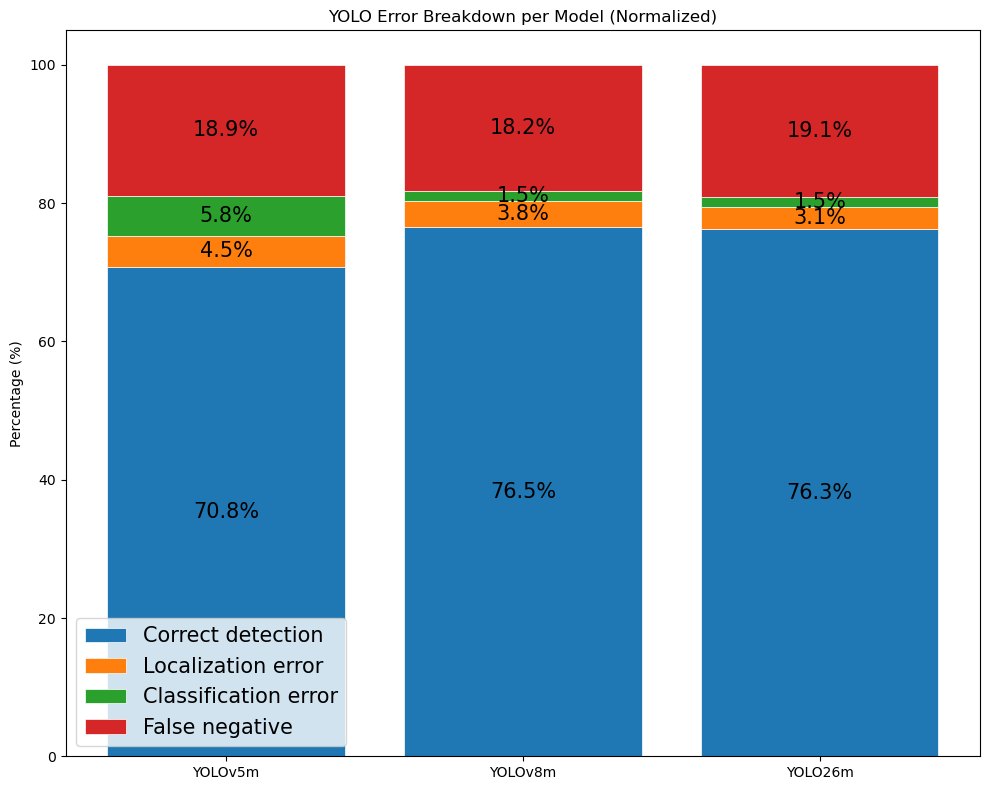

In [8]:
categories = [
    "Correct detection",
    "Localization error",
    "Classification error",
    "False negative"
]

models = list(results.keys())

# convert to percentages
values = np.array([
    [results[m][c] for c in categories]
    for m in models
], dtype=float)

# normalize per model
row_sums = values.sum(axis=1, keepdims=True)
percentages = (values / row_sums) * 100

plt.figure(figsize=(10, 8))

bottom = np.zeros(len(models))

for i, cat in enumerate(categories):
    bars = plt.bar(models, percentages[:, i], bottom=bottom, label=cat, edgecolor='white', linewidth=0.5)

    # add text labels inside each segment
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:  # avoid clutter for zero values
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + height / 2,
                f"{height:.1f}%",
                ha='center',
                va='center',
                fontsize=15
            )

    bottom += percentages[:, i]

plt.ylabel("Percentage (%)")
plt.title("YOLO Error Breakdown per Model (Normalized)")
plt.legend(prop={"size": 15})
plt.tight_layout()
plt.show()

### 2. Per-Class Failure

In [9]:
def analyze_model_per_class(gt_dir, pred_dir, iou_thr=0.5):
    gt_counts = defaultdict(int)
    fn_counts = defaultdict(int)

    loc_errors = defaultdict(int)
    cls_errors = defaultdict(int)

    for gt_file in gt_dir.glob("*.txt"):
        pred_file = pred_dir / gt_file.name

        gt = load_labels(gt_file)
        pred = load_labels(pred_file)

        gt_used = set()

        # count GT per class
        for g in gt:
            gt_counts[int(g[0])] += 1

        for p in pred:
            p_cls = int(p[0])
            p_box = yolo_to_xyxy(p[1:])

            best_iou = 0
            best_gi = -1

            for gi, g in enumerate(gt):
                if gi in gt_used:
                    continue

                i = iou(p_box, yolo_to_xyxy(g[1:]))
                if i > best_iou:
                    best_iou = i
                    best_gi = gi

            if best_gi == -1:
                continue

            g_cls = int(gt[best_gi][0])

            if best_iou >= iou_thr and p_cls == g_cls:
                gt_used.add(best_gi)

            elif best_iou >= iou_thr and p_cls != g_cls:
                cls_errors[g_cls] += 1
                gt_used.add(best_gi)

            elif best_iou < iou_thr and p_cls == g_cls:
                loc_errors[g_cls] += 1
                gt_used.add(best_gi)

        # false negatives per class
        for gi, g in enumerate(gt):
            if gi not in gt_used:
                fn_counts[int(g[0])] += 1

    return {
        "gt": gt_counts,
        "fn": fn_counts,
        "loc": loc_errors,
        "cls": cls_errors
    }

In [10]:
results_pc = {
    "YOLOv5m": analyze_model_per_class(GROUND_TRUTH_DIR, YOLOV5M_DIR),
    "YOLOv8m": analyze_model_per_class(GROUND_TRUTH_DIR, YOLOV8M_DIR),
    "YOLO26m": analyze_model_per_class(GROUND_TRUTH_DIR, YOLO26M_DIR),
}

In [11]:
all_classes = sorted(
    set().union(*[
        results_pc[m]["gt"].keys()
        for m in results_pc
    ])
)

In [12]:
class_names = {
    0: "person",
    1: "ear",
    2: "ear-mufs",
    3: "face",
    4: "face-guard",
    5: "face-mask-medical",
    6: "foot",
    7: "tools",
    8: "glasses",
    9: "gloves",
    10: "helmet",
    11: "hands",
    12: "head",
    13: "medical-suit",
    14: "shoes",
    15: "safety-suit",
    16: "safety-vest",
}

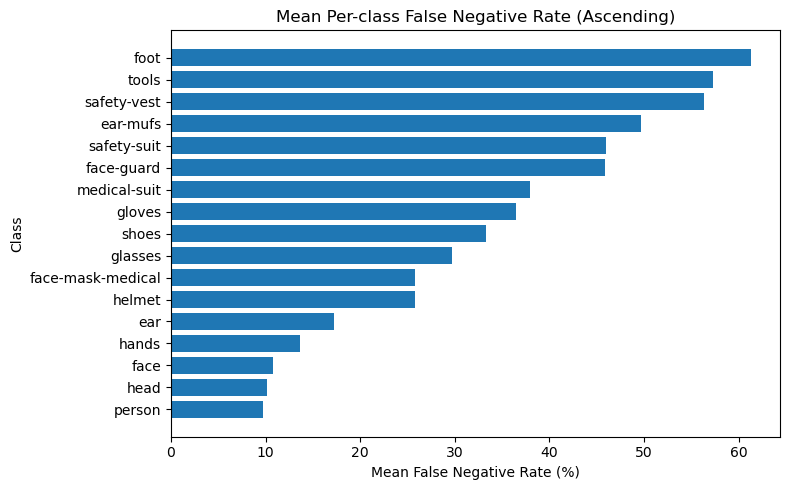

In [13]:
models = list(results_pc.keys())

# sorted class IDs
all_classes = sorted(class_names.keys())
class_labels = [class_names[c] for c in all_classes]

fn_rates = np.array([
    [
        (results_pc[m]["fn"].get(c, 0) / results_pc[m]["gt"].get(c, 1)) * 100
        for c in all_classes
    ]
    for m in models
], dtype=float)

mean_fn = fn_rates.mean(axis=0)  # shape = (num_classes,)

sorted_idx = np.argsort(mean_fn)  # ascending order
mean_fn_sorted = mean_fn[sorted_idx]
classes_sorted = [all_classes[i] for i in sorted_idx]
labels_sorted = [class_names[c] for c in classes_sorted]

plt.figure(figsize=(8, 5))

y = np.arange(len(classes_sorted))

plt.barh(y, mean_fn_sorted)
plt.yticks(y, labels_sorted)
plt.xlabel("Mean False Negative Rate (%)")
plt.ylabel("Class")
plt.title("Mean Per-class False Negative Rate (Ascending)")
plt.tight_layout()
plt.show()

In [14]:
rows = []

for ci, c in enumerate(all_classes):
    class_label = class_names[c]

    # FN rates per model (already percentages)
    fn_vals = fn_rates[:, ci]

    # localization + classification error rates per model
    loc_vals = np.array([
        (results_pc[m]["loc"].get(c, 0) / results_pc[m]["gt"].get(c, 1)) * 100
        for m in models
    ])

    cls_vals = np.array([
        (results_pc[m]["cls"].get(c, 0) / results_pc[m]["gt"].get(c, 1)) * 100
        for m in models
    ])

    # mean across models
    mean_fn = fn_vals.mean()
    mean_loc = loc_vals.mean()
    mean_cls = cls_vals.mean()

    # dominant error
    dominant_error = max(
        [("FN", mean_fn), ("Loc", mean_loc), ("Cls", mean_cls)],
        key=lambda x: x[1]
    )[0]

    rows.append({
        "Class": class_label,
        "Dominant Error": dominant_error,
        "Mean FN": mean_fn,
        "v5m": fn_vals[0],
        "v8m": fn_vals[1],
        "26m": fn_vals[2],
    })

In [15]:
df = pd.DataFrame(rows)

# sort by hardest (highest mean FN)
df = df.sort_values("Mean FN", ascending=False)

# keep top-N hardest classes
TOP_N = 5
df_top = df.head(TOP_N)

In [16]:
df_display = df_top[["Class", "Dominant Error", "v5m", "v8m", "26m"]].copy()

for col in ["v5m", "v8m", "26m"]:
    df_display[col] = df_display[col].map(lambda x: f"{x:.0f}%")

df_display

,Class,Dominant Error,v5m,v8m,26m
6,foot,FN,57%,61%,66%
7,tools,FN,54%,56%,62%
16,safety-vest,FN,55%,54%,61%
2,ear-mufs,FN,43%,47%,59%
15,safety-suit,FN,47%,47%,44%


### 3. Effect of Object Size

In [17]:
def collect_gt_areas(gt_dir):
    areas = []
    for gt_file in gt_dir.glob("*.txt"):
        gt = load_labels(gt_file)
        for g in gt:
            _, _, w, h, _ = g
            areas.append(w * h)
    return np.array(areas)

gt_areas = collect_gt_areas(GROUND_TRUTH_DIR)
q1, q2, q3 = np.percentile(gt_areas, [25, 50, 75])

In [18]:
def size_bin(box):
    _, _, w, h = box
    area = w * h

    if area <= q1:
        return "Q1 (small)"
    elif area <= q2:
        return "Q2"
    elif area <= q3:
        return "Q3"
    else:
        return "Q4 (large)"

In [19]:
def recall_vs_size(gt_dir, pred_dir, iou_thr=0.5):
    total = defaultdict(int)
    detected = defaultdict(int)

    for gt_file in gt_dir.glob("*.txt"):
        pred_file = pred_dir / gt_file.name
        gt = load_labels(gt_file)
        pred = load_labels(pred_file)

        gt_used = set()

        for p in pred:
            p_cls = int(p[0])
            p_box = yolo_to_xyxy(p[1:])

            best_iou = 0
            best_gi = -1

            for gi, g in enumerate(gt):
                if gi in gt_used:
                    continue
                i = iou(p_box, yolo_to_xyxy(g[1:]))
                if i > best_iou:
                    best_iou = i
                    best_gi = gi

            if best_gi != -1 and best_iou >= iou_thr and int(gt[best_gi][0]) == p_cls:
                b = size_bin(gt[best_gi][1:])
                detected[b] += 1
                gt_used.add(best_gi)

        for g in gt:
            b = size_bin(g[1:])
            total[b] += 1

    recall = {b: detected[b] / total[b] for b in total}
    return recall

In [20]:
models = {
    "YOLOv5m": YOLOV5M_DIR,
    "YOLOv8m": YOLOV8M_DIR,
    "YOLO26m": YOLO26M_DIR,
}

recall_data = {
    name: recall_vs_size(GROUND_TRUTH_DIR, pred_dir)
    for name, pred_dir in models.items()
}

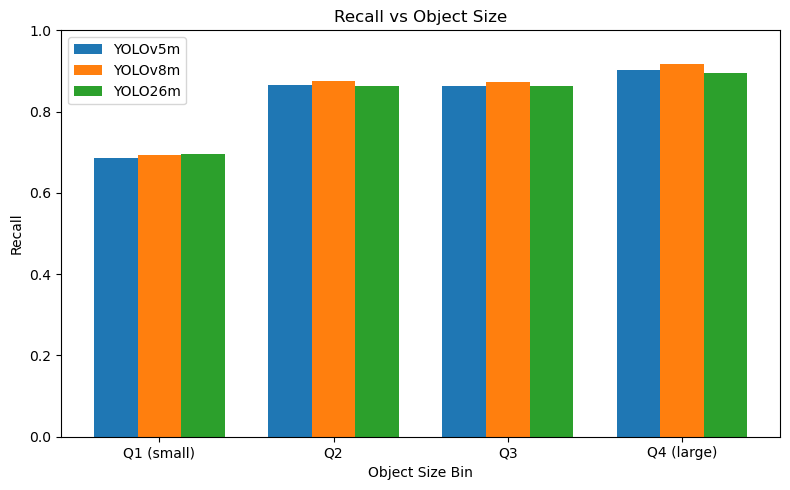

In [21]:
bins = ["Q1 (small)", "Q2", "Q3", "Q4 (large)"]
x = np.arange(len(bins))
width = 0.25

plt.figure(figsize=(8, 5))

for i, (model, recalls) in enumerate(recall_data.items()):
    values = [recalls[b] for b in bins]
    plt.bar(x + i * width, values, width, label=model)

plt.xticks(x + width, bins)
plt.ylabel("Recall")
plt.xlabel("Object Size Bin")
plt.title("Recall vs Object Size")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
def count_labels_per_bin(gt_dir):
    counts = Counter()

    for gt_file in gt_dir.glob("*.txt"):
        gt = load_labels(gt_file)
        for g in gt:
            b = size_bin(g[1:])
            counts[b] += 1

    return counts

Q3: 1476
Q2: 2273
Q1 (small): 9163
Q4 (large): 2446


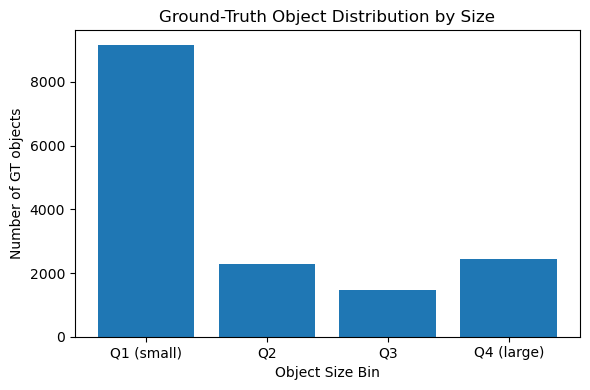

In [23]:
bin_counts = count_labels_per_bin(GROUND_TRUTH_DIR)

for b, c in bin_counts.items():
    print(f"{b}: {c}")

bins = ["Q1 (small)", "Q2", "Q3", "Q4 (large)"]
counts = [bin_counts[b] for b in bins]

plt.figure(figsize=(6,4))
plt.bar(bins, counts)
plt.ylabel("Number of GT objects")
plt.xlabel("Object Size Bin")
plt.title("Ground-Truth Object Distribution by Size")
plt.tight_layout()
plt.show()

### 4. Qualitative Failure Examples

In [24]:
IMAGE_ROOT = Path("../data_for_yolo/images")
IMAGES_DIR = IMAGE_ROOT / "test"

In [25]:
pred_dirs = {
    "YOLOv5m": YOLOV5M_DIR,
    "YOLOv8m": YOLOV8M_DIR,
    "YOLO26m": YOLO26M_DIR
}

In [26]:
def find_failures(gt_dir, pred_dir, iou_thr=0.5):
    failures = {
        "fn": set(),
        "cls": set(),
        "loc": set()
    }

    for gt_file in gt_dir.glob("*.txt"):
        pred_file = pred_dir / gt_file.name

        gt = load_labels(gt_file)
        pred = load_labels(pred_file)

        gt_used = set()

        for p in pred:
            p_cls = int(p[0])
            p_box = yolo_to_xyxy(p[1:])

            best_iou = 0
            best_gi = -1

            for gi, g in enumerate(gt):
                if gi in gt_used:
                    continue

                i = iou(p_box, yolo_to_xyxy(g[1:]))
                if i > best_iou:
                    best_iou = i
                    best_gi = gi

            if best_gi == -1:
                continue

            g_cls = int(gt[best_gi][0])

            # classification error
            if best_iou >= iou_thr and p_cls != g_cls:
                failures["cls"].add(gt_file.name)
                gt_used.add(best_gi)

            # localization error
            elif best_iou < iou_thr and p_cls == g_cls:
                failures["loc"].add(gt_file.name)
                gt_used.add(best_gi)

            # correct match
            elif best_iou >= iou_thr and p_cls == g_cls:
                gt_used.add(best_gi)

        # false negatives
        for gi in range(len(gt)):
            if gi not in gt_used:
                failures["fn"].add(gt_file.name)
                break

    return failures

In [27]:
failures_by_model = {
    name: find_failures(GROUND_TRUTH_DIR, pred_dir)
    for name, pred_dir in pred_dirs.items()
}

In [28]:
def collect_representative_images(failures_by_model, n=2):
    selected = set()

    for model, failures in failures_by_model.items():

        # prioritize FN (your main finding)
        for img in list(failures["fn"])[:n]:
            selected.add(img)

        # localization errors
        for img in list(failures["loc"])[:n]:
            selected.add(img)

        # classification errors
        for img in list(failures["cls"])[:n]:
            selected.add(img)

    return list(selected)

In [29]:
def plot_comparison(image_name, gt_dir, pred_dirs, image_root):

    img_path = image_root / image_name.replace(".txt", ".jpeg")

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt = load_labels(gt_dir / image_name)

    fig, axes = plt.subplots(1, len(pred_dirs) + 1, figsize=(20, 6))

    # ---------------- GT ----------------
    axes[0].imshow(img)
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    for g in gt:
        x1, y1, x2, y2 = yolo_to_xyxy(g[1:])

        rect = patches.Rectangle(
            (x1 * img.shape[1], y1 * img.shape[0]),
            (x2 - x1) * img.shape[1],
            (y2 - y1) * img.shape[0],
            linewidth=2,
            edgecolor='green',
            facecolor='none'
        )
        axes[0].add_patch(rect)

        cls = class_names.get(int(g[0]), str(int(g[0])))
        axes[0].text(
            x1 * img.shape[1],
            y1 * img.shape[0] - 5,
            str(cls),
            color="green",
            fontsize=14
        )

    # ---------------- Predictions ----------------
    for i, (model, pred_dir) in enumerate(pred_dirs.items()):
        axes[i + 1].imshow(img)
        axes[i + 1].set_title(model)
        axes[i + 1].axis("off")

        pred = load_labels(pred_dir / image_name)

        for p in pred:
            x1, y1, x2, y2 = yolo_to_xyxy(p[1:])

            rect = patches.Rectangle(
                (x1 * img.shape[1], y1 * img.shape[0]),
                (x2 - x1) * img.shape[1],
                (y2 - y1) * img.shape[0],
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            axes[i + 1].add_patch(rect)

            cls = class_names.get(int(p[0]), str(int(p[0])))
            axes[i + 1].text(
                x1 * img.shape[1],
                y1 * img.shape[0] - 5,
                str(cls),
                color="red",
                fontsize=14
            )

    plt.tight_layout()
    plt.show()

In [ ]:
# 1. compute failures per model
failures_by_model = {
    name: find_failures(GROUND_TRUTH_DIR, pred_dir)
    for name, pred_dir in pred_dirs.items()
}

# 2. print stats
for m, f in failures_by_model.items():
    print(m, {k: len(v) for k, v in f.items()})

# 3. select representative images
selected_images = collect_representative_images(failures_by_model, n=3)

print("Selected images:", len(selected_images))
print(selected_images[:6])

YOLOv5m {'fn': 870, 'cls': 514, 'loc': 437}
YOLOv8m {'fn': 832, 'cls': 165, 'loc': 384}
YOLO26m {'fn': 904, 'cls': 152, 'loc': 323}
Selected images: 23
['pexels-photo-6129155.txt', 'pexels-photo-11881296.txt', 'pexels-photo-5684440.txt', 'pexels-photo-7482642.txt', 'pexels-photo-15947457.txt', 'pexels-photo-12555018.txt']


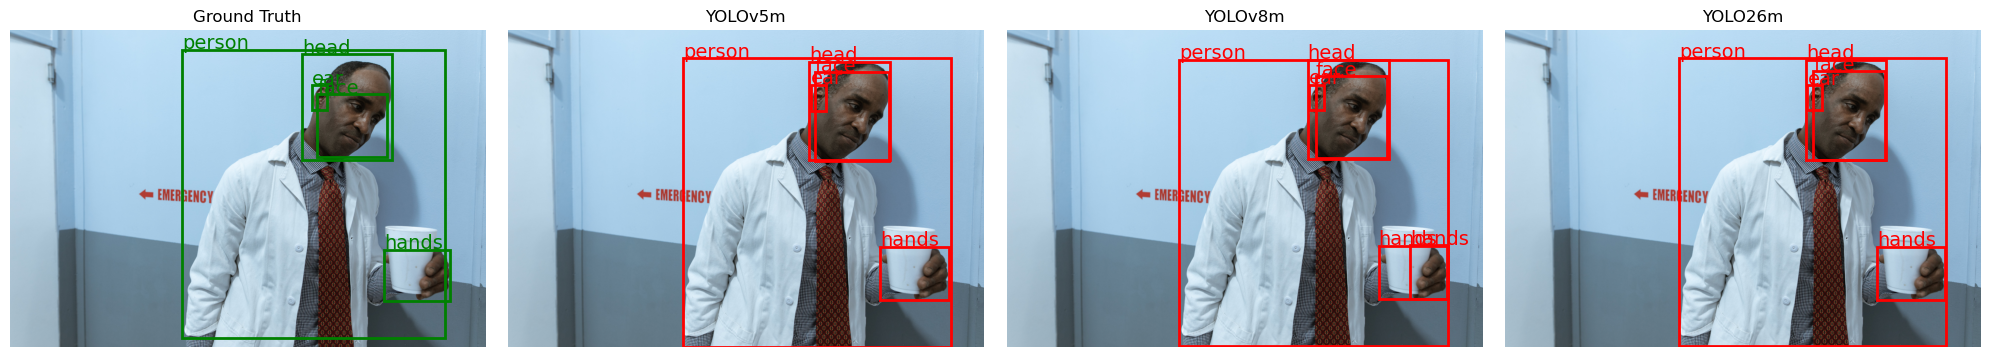

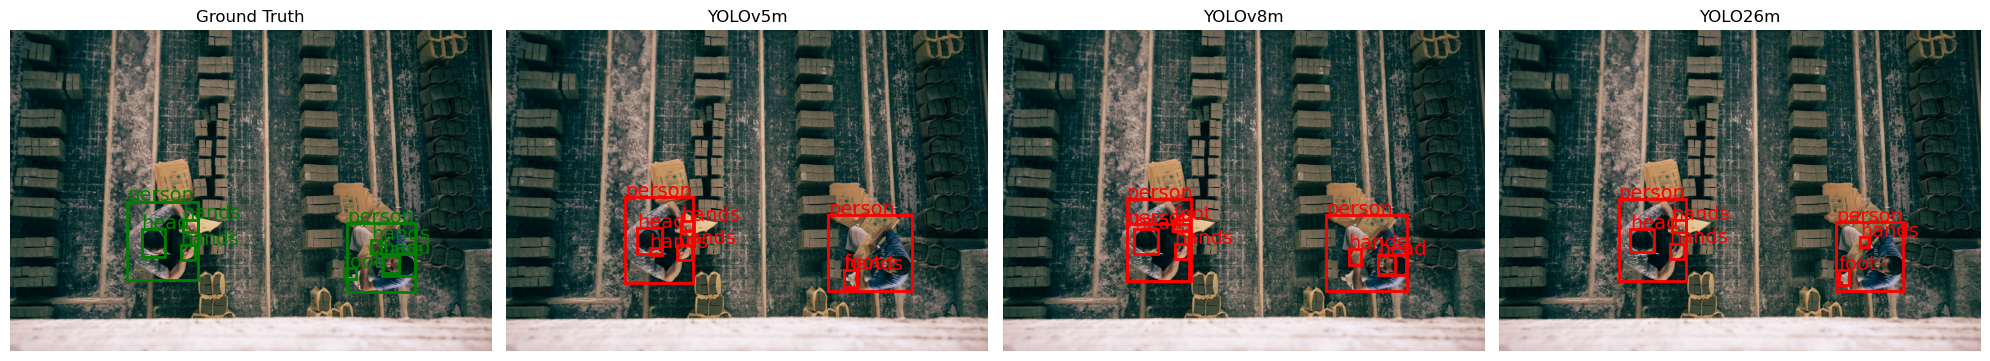

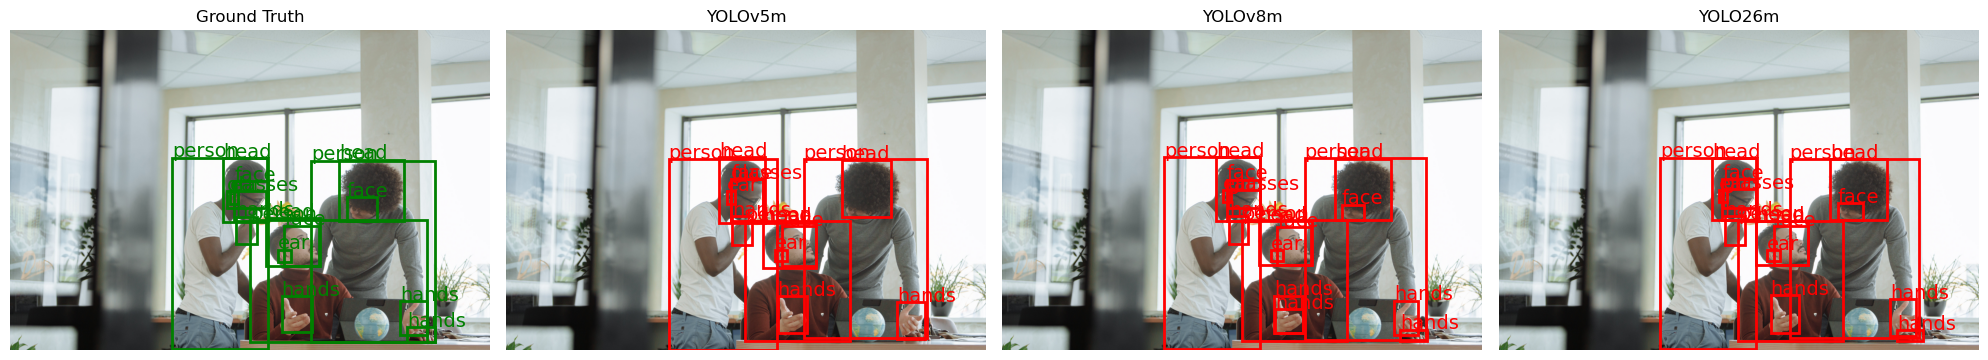

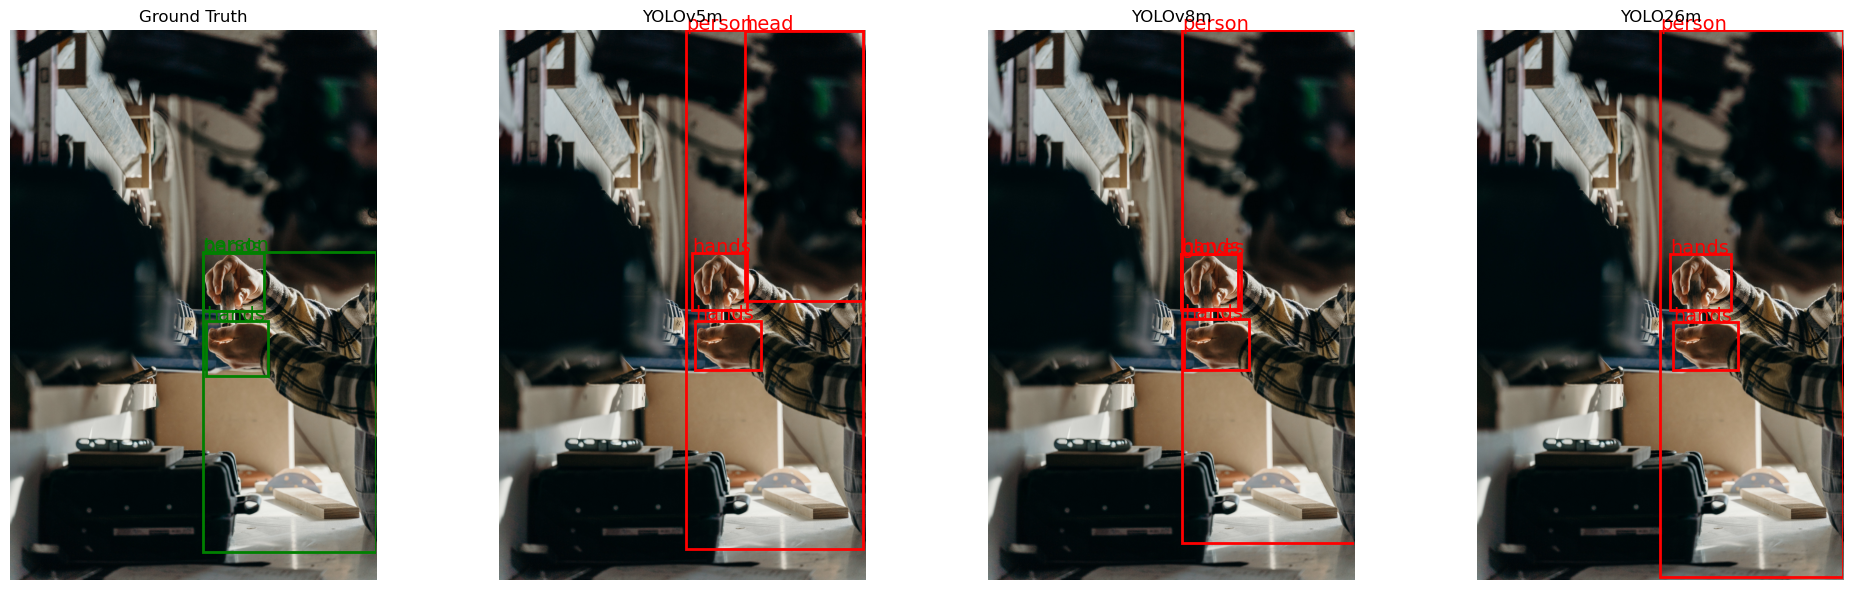

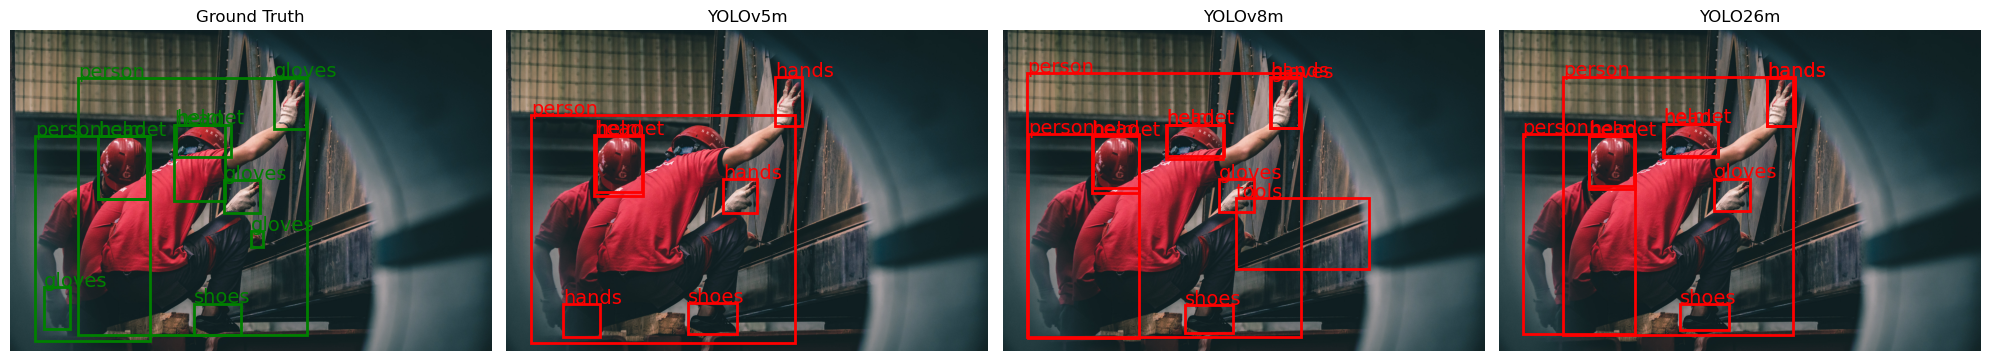

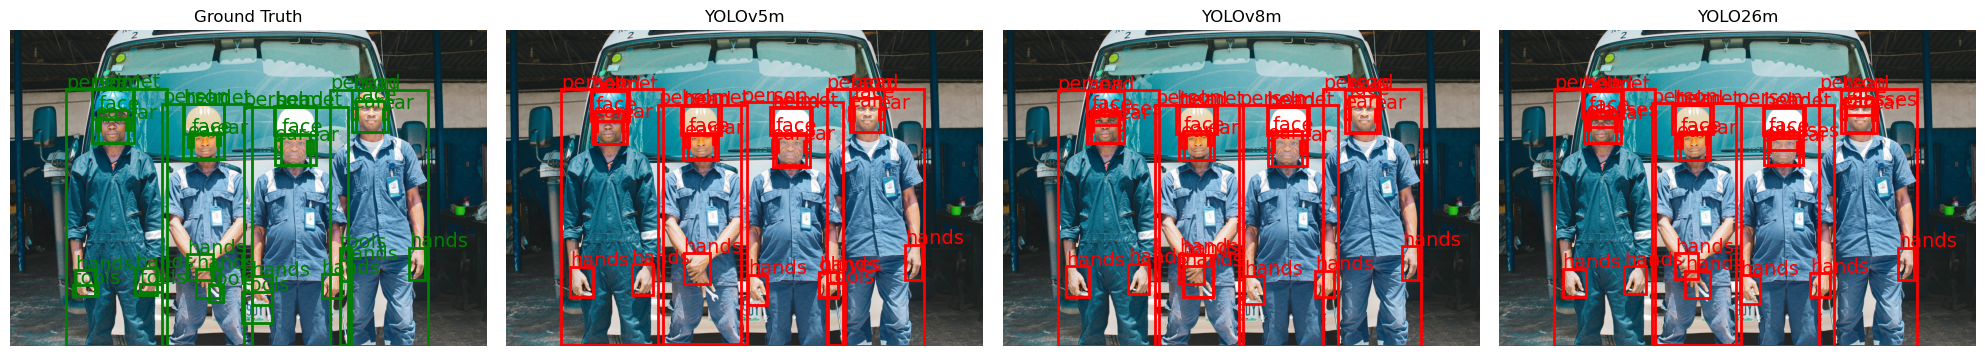

In [31]:
for img_name in selected_images[:6]:
    plot_comparison(
        img_name,
        GROUND_TRUTH_DIR,
        pred_dirs,
        IMAGE_ROOT / "test"
    )